In [1]:
import sys
print(sys.executable)

d:\Smart-Lender\venv\Scripts\python.exe


In [2]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

import sklearn
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

import imblearn
from xgboost import XGBClassifier

In [3]:
data = pd.read_csv("../dataset/loan_prediction.csv")

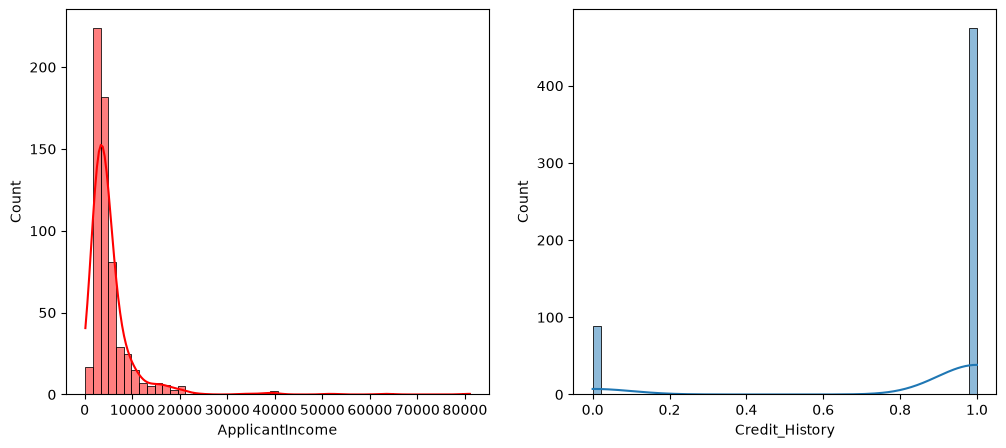

In [4]:

plt.figure(figsize=(12,5))
plt.subplot(121)
sns.histplot(data['ApplicantIncome'], color='r', kde=True)
plt.subplot(122)
sns.histplot(data['Credit_History'], kde=True)
plt.show()


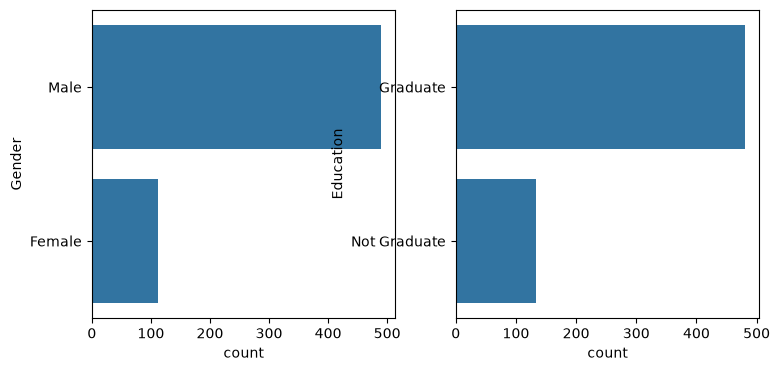

In [5]:
plt.figure(figsize=(18, 4))

plt.subplot(1, 4, 1)
sns.countplot(data['Gender'])

plt.subplot(1, 4, 2)
sns.countplot(data['Education'])

plt.show()

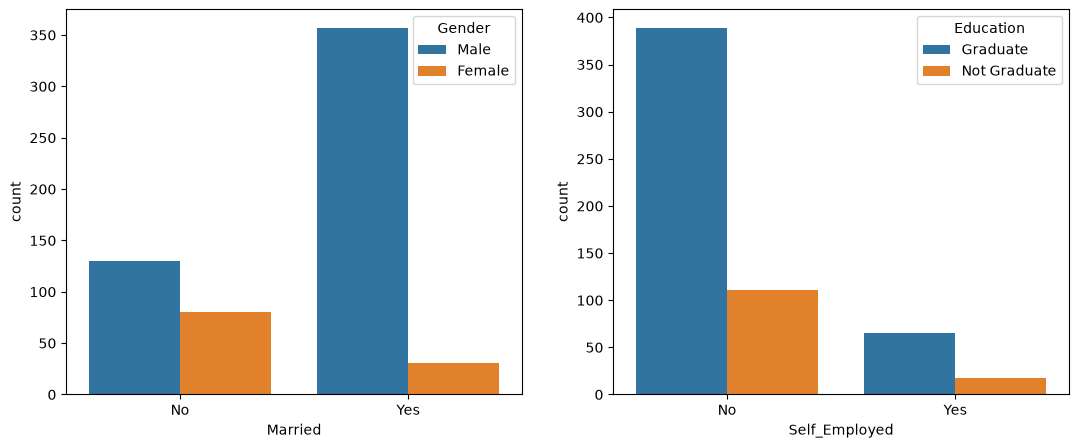

In [6]:
plt.figure(figsize=(20,5))

plt.subplot(131)
sns.countplot(x='Married', hue='Gender', data=data)

plt.subplot(132)
sns.countplot(x='Self_Employed', hue='Education', data=data)

plt.show()

d:\Smart-Lender\venv\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 45.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
d:\Smart-Lender\venv\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 61.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
d:\Smart-Lender\venv\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 25.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


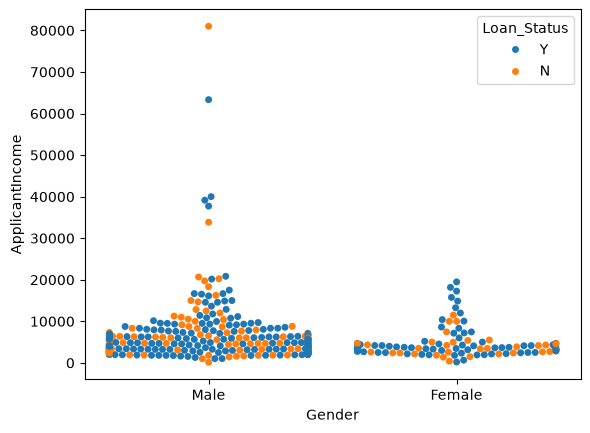

In [7]:
sns.swarmplot(
    x='Gender',
    y='ApplicantIncome',
    hue='Loan_Status',
    data=data
)
plt.show()

In [8]:
import jupyterthemes as jt

In [9]:
data['Gender'] = data['Gender'].map({'Female': 1, 'Male': 0})
data['Property_Area'] = data['Property_Area'].map({'Urban': 2, 'Semiurban': 1, 'Rural': 0})
data['Married'] = data['Married'].map({'Yes': 1, 'No': 0})
data['Education'] = data['Education'].map({'Graduate': 1, 'Not Graduate': 0})
data['Loan_Status'] = data['Loan_Status'].map({'Y': 1, 'N': 0})

In [10]:
data['Gender']=data['Gender'].map({'Female':1,'Male':0})
data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,NaN,0.0,0,1,No,5849,0.0,NaN,360.0,1.0,2,1
1,LP001003,NaN,1.0,1,1,No,4583,1508.0,128.0,360.0,1.0,0,0
2,LP001005,NaN,1.0,0,1,Yes,3000,0.0,66.0,360.0,1.0,2,1
3,LP001006,NaN,1.0,0,0,No,2583,2358.0,120.0,360.0,1.0,2,1
4,LP001008,NaN,0.0,0,1,No,6000,0.0,141.0,360.0,1.0,2,1


In [11]:
data['Property_Area']=data['Property_Area'].map({'Urban':2,'Semiurban':1,'Rural':0})

In [12]:
data.isnull().sum()

Loan_ID                0
Gender               614
Married                3
Dependents            15
Education              0
Self_Employed         32
ApplicantIncome        0
CoapplicantIncome      0
LoanAmount            22
Loan_Amount_Term      14
Credit_History        50
Property_Area        614
Loan_Status            0
dtype: int64

In [13]:
print(data.shape)
print(data.columns.tolist())
print(data.head())
print(data["Gender"].mode())
print(data["Gender"].value_counts(dropna=False))


(614, 13)
['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']
    Loan_ID  Gender  Married Dependents  Education Self_Employed  \
0  LP001002     NaN      0.0          0          1            No   
1  LP001003     NaN      1.0          1          1            No   
2  LP001005     NaN      1.0          0          1           Yes   
3  LP001006     NaN      1.0          0          0            No   
4  LP001008     NaN      0.0          0          1            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000       

In [14]:
data = pd.read_csv("../dataset/loan_prediction.csv")   # or the correct path
data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [15]:
data['Gender'].value_counts(dropna=False)

Gender
Male      489
Female    112
NaN        13
Name: count, dtype: int64

In [16]:
data['Gender'] = data['Gender'].fillna(data['Gender'].mode().iloc[0])

In [17]:
data['Married'] = data['Married'].fillna(data['Married'].mode().iloc[0])

In [18]:
data['Dependents']=data['Dependents'].str.replace('+','')

In [19]:
data['Dependents'] = data['Dependents'].fillna(data['Dependents'].mode().iloc[0])

In [20]:
data['Self_Employed'] = data['Self_Employed'].fillna(data['Self_Employed'].mode().iloc[0])

In [21]:
data['LoanAmount'] = data['LoanAmount'].fillna(data['LoanAmount'].mode().iloc[0])

In [22]:
data.isnull().sum()

Loan_ID               0
Gender                0
Married               0
Dependents            0
Education             0
Self_Employed         0
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            0
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [23]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             614 non-null    str    
 2   Married            614 non-null    str    
 3   Dependents         614 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      614 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         614 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 62.5 KB


In [24]:
data['Gender'] = data['Gender'].map({'Male': 1, 'Female': 0})
data['Married'] = data['Married'].map({'Yes': 1, 'No': 0})
data['Education'] = data['Education'].map({'Graduate': 1, 'Not Graduate': 0})
data['Self_Employed'] = data['Self_Employed'].map({'Yes': 1, 'No': 0})
data['Loan_Status'] = data['Loan_Status'].map({'Y': 1, 'N': 0})

In [25]:
data.isnull().sum()

Loan_ID               0
Gender                0
Married               0
Dependents            0
Education             0
Self_Employed         0
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            0
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [26]:
data['Loan_Amount_Term'] = data['Loan_Amount_Term'].fillna(
    data['Loan_Amount_Term'].mode().iloc[0]
)

data['Credit_History'] = data['Credit_History'].fillna(
    data['Credit_History'].mode().iloc[0]
)

In [27]:
data.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [28]:
data['Gender']=data['Gender'].astype('int64')
data['Married']=data['Married'].astype('int64')
data['Dependents']=data['Dependents'].astype('int64')
data['Self_Employed']=data['Self_Employed'].astype('int64')
data['CoapplicantIncome']=data['CoapplicantIncome'].astype('int64')
data['LoanAmount']=data['LoanAmount'].astype('int64')
data['Loan_Amount_Term'] = data['Loan_Amount_Term'].astype('int64')
data['Credit_History'] = data['Credit_History'].astype('int64')

In [29]:
data.info

<bound method DataFrame.info of       Loan_ID  Gender  Married  Dependents  Education  Self_Employed  \
0    LP001002       1        0           0          1              0   
1    LP001003       1        1           1          1              0   
2    LP001005       1        1           0          1              1   
3    LP001006       1        1           0          0              0   
4    LP001008       1        0           0          1              0   
..        ...     ...      ...         ...        ...            ...   
609  LP002978       0        0           0          1              0   
610  LP002979       1        1           3          1              0   
611  LP002983       1        1           1          1              0   
612  LP002984       1        1           2          1              0   
613  LP002990       0        0           0          1              1   

     ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0               5849          

In [30]:
X = data.drop(['Loan_ID','Loan_Status'],axis=1)

y = data['Loan_Status']

In [31]:
print(X.dtypes)

Gender               int64
Married              int64
Dependents           int64
Education            int64
Self_Employed        int64
ApplicantIncome      int64
CoapplicantIncome    int64
LoanAmount           int64
Loan_Amount_Term     int64
Credit_History       int64
Property_Area          str
dtype: object


In [32]:
print(data['Property_Area'].unique())

<StringArray>
['Urban', 'Rural', 'Semiurban']
Length: 3, dtype: str


In [33]:
data['Property_Area'] = data['Property_Area'].map({
    'Rural': 0,
    'Semiurban': 1,
    'Urban': 2
})

In [34]:
data['Property_Area'] = data['Property_Area'].astype(int)

In [35]:
X = data.drop(['Loan_ID', 'Loan_Status'], axis=1)
y = data['Loan_Status']

In [36]:
print(X.dtypes)

Gender               int64
Married              int64
Dependents           int64
Education            int64
Self_Employed        int64
ApplicantIncome      int64
CoapplicantIncome    int64
LoanAmount           int64
Loan_Amount_Term     int64
Credit_History       int64
Property_Area        int64
dtype: object


In [37]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_bal, y_bal = smote.fit_resample(X, y)

In [38]:
print(y.value_counts())
print(y_bal.value_counts())

Loan_Status
1    422
0    192
Name: count, dtype: int64
Loan_Status
1    422
0    422
Name: count, dtype: int64


In [39]:
names=X_bal.columns

In [40]:
sc=StandardScaler()
x_bal=sc.fit_transform(X_bal)

In [41]:
X_bal=pd.DataFrame(X_bal,columns=names)

In [42]:
X_train,X_test,y_train,y_test=train_test_split(
    X_bal,y_bal,test_size=0.33,random_state=42
)

In [43]:
X_train.shape

(565, 11)

In [44]:
X_test.shape

(279, 11)

In [55]:
def decisionTree(X_train, X_test, y_train, y_test):
    model = DecisionTreeClassifier()
    model.fit(X_train, y_train)

    y_tr = model.predict(X_train)
    print("Training Accuracy:", accuracy_score(y_train, y_tr))

    y_pred = model.predict(X_test)
    print("Testing Accuracy:", accuracy_score(y_test, y_pred))

    return model

In [56]:
def RandomForest(X_train, X_test, y_train, y_test):
    model = RandomForestClassifier(random_state=42)
    model.fit(X_train, y_train)

    y_tr = model.predict(X_train)
    print("Training Accuracy:", accuracy_score(y_train, y_tr))

    y_pred = model.predict(X_test)
    print("Testing Accuracy:", accuracy_score(y_test, y_pred))

    return model

In [66]:
rf_model = RandomForest(X_train, X_test, y_train, y_test)
import pickle
pickle.dump(model, open("rdf.pkl", "wb"))

Training Accuracy: 1.0
Testing Accuracy: 0.7956989247311828


In [57]:
def KNN(X_train, X_test, y_train, y_test):
    model = KNeighborsClassifier()
    model.fit(X_train, y_train)

    y_tr = model.predict(X_train)
    print("Training Accuracy:", accuracy_score(y_train, y_tr))

    y_pred = model.predict(X_test)
    print("Testing Accuracy:", accuracy_score(y_test, y_pred))

    return model

In [59]:
KNN(X_train,X_test,y_train,y_test)

Training Accuracy: 0.7539823008849558
Testing Accuracy: 0.6272401433691757


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [58]:
def XGB(X_train, X_test, y_train, y_test):
    model = GradientBoostingClassifier(random_state=42)
    model.fit(X_train, y_train)

    y_tr = model.predict(X_train)
    print("Training Accuracy:", accuracy_score(y_train, y_tr))

    y_pred = model.predict(X_test)
    print("Testing Accuracy:", accuracy_score(y_test, y_pred))

    return model

In [64]:
model = XGB(X_train, X_test, y_train, y_test)

pickle.dump(model, open("model.pkl", "wb"))

Training Accuracy: 0.9345132743362832
Testing Accuracy: 0.7921146953405018


In [68]:
import pickle

pickle.dump(rf_model, open("../Flask/rdf.pkl", "wb"))